In [1]:
!pip install -U langgraph-supervisor langchain-groq langchain langchain-community langgraph ddgs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.7/164.7 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 62.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.2/250.2 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.1/572.1 kB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 80.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.7 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: langchain-core
    Found

### LangGraph Math and Research Agent with Groq
- This notebook builds a LangGraph tool-calling agent using Groq. It can answer general questions, perform reliable mathematical calculations with a calculator tool, and search the web when current or factual information is required

### Import libraries

In [30]:
import os
import ast
import math
import operator as op
from getpass import getpass
from IPython.display import Image, display
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage
from langgraph.graph import START, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from typing import Annotated
from typing_extensions import TypedDict

### Configure Groq

In [31]:
if not os.getenv("GROQ_API_KEY"):
    os.environ["GROQ_API_KEY"] = getpass("key_Prajwal_Api")

llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0,
    api_key=os.environ["GROQ_API_KEY"]
)


### Define the graph state

In [32]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

### Create the web search tool

In [33]:
from langchain_community.tools import DuckDuckGoSearchRun

search = DuckDuckGoSearchRun()

def search_duckduckgo(query: str) -> str:
    """Search the web using DuckDuckGo and return the search results."""
    return search.invoke(query)


### Create the mathematics calculator tool

In [34]:
_ALLOWED_BIN_OPS = {
    ast.Add: op.add,
    ast.Sub: op.sub,
    ast.Mult: op.mul,
    ast.Div: op.truediv,
    ast.Pow: op.pow,
    ast.Mod: op.mod,
    ast.FloorDiv: op.floordiv
}

_ALLOWED_UNARY_OPS = {
    ast.UAdd: op.pos,
    ast.USub: op.neg
}

_ALLOWED_FUNCTIONS = {
    "abs": abs,
    "round": round,
    "sqrt": math.sqrt,
    "sin": math.sin,
    "cos": math.cos,
    "tan": math.tan,
    "asin": math.asin,
    "acos": math.acos,
    "atan": math.atan,
    "log": math.log,
    "log10": math.log10,
    "exp": math.exp,
    "factorial": math.factorial,
    "ceil": math.ceil,
    "floor": math.floor
}

_ALLOWED_CONSTANTS = {
    "pi": math.pi,
    "e": math.e
}

def _evaluate_math(node):
    if isinstance(node, ast.Expression):
        return _evaluate_math(node.body)

    if isinstance(node, ast.Constant) and isinstance(node.value, (int, float)):
        return node.value

    if isinstance(node, ast.BinOp) and type(node.op) in _ALLOWED_BIN_OPS:
        left = _evaluate_math(node.left)
        right = _evaluate_math(node.right)
        return _ALLOWED_BIN_OPS[type(node.op)](left, right)

    if isinstance(node, ast.UnaryOp) and type(node.op) in _ALLOWED_UNARY_OPS:
        return _ALLOWED_UNARY_OPS[type(node.op)](_evaluate_math(node.operand))

    if isinstance(node, ast.Call) and isinstance(node.func, ast.Name):
        if node.func.id not in _ALLOWED_FUNCTIONS:
            raise ValueError(f"Unsupported function: {node.func.id}")
        args = [_evaluate_math(arg) for arg in node.args]
        return _ALLOWED_FUNCTIONS[node.func.id](*args)

    if isinstance(node, ast.Name) and node.id in _ALLOWED_CONSTANTS:
        return _ALLOWED_CONSTANTS[node.id]

    raise ValueError("Unsupported mathematical expression.")

def calculate(expression: str) -> str:
    """Evaluate a mathematical expression accurately and return the result."""
    try:
        tree = ast.parse(expression.strip(), mode="eval")
        result = _evaluate_math(tree)
        if isinstance(result, float) and result.is_integer():
            result = int(result)
        return str(result)
    except ZeroDivisionError:
        return "Error: division by zero."
    except (ValueError, TypeError, OverflowError, SyntaxError) as exc:
        return f"Error: {exc}"


### Add tool descriptions and bind tools

In [35]:
tools = [search_duckduckgo, calculate]
llm_with_tools = llm.bind_tools(tools)

### Define the assistant

In [36]:
def chatbot(state: State):
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}

### Build the LangGraph workflow

In [37]:
graph_builder = StateGraph(State)

graph_builder.add_node("assistant", chatbot)
graph_builder.add_node("tools", ToolNode(tools))

graph_builder.add_edge(START, "assistant")
graph_builder.add_conditional_edges("assistant", tools_condition)
graph_builder.add_edge("tools", "assistant")

react_graph = graph_builder.compile()

### Visualize the graph

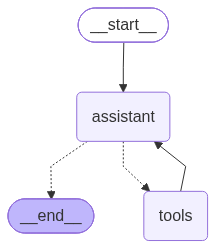

In [38]:
display(Image(react_graph.get_graph().draw_mermaid_png()))

### Test the Groq model

In [42]:
print(llm.invoke("Hello").content)

Hello! How can I assist you today?


### Test a simple calculation

In [43]:
question = "Calculate 20% of 500, multiply the result by 4, and add 50."

response = react_graph.invoke({
    "messages": [HumanMessage(content=question)]
})

print(response["messages"][-1].content)

First, find 20 % of 500:

\(0.20 \times 500 = 100\)

Next, multiply that result by 4:

\(100 \times 4 = 400\)

Finally, add 50:

\(400 + 50 = 450\)

**Result: 450**


### Test a complex mathematical question

In [44]:
question = "What is the value of sqrt(144) + 2^5 + 20% of 500?"

response = react_graph.invoke({
    "messages": [HumanMessage(content=question)]
})

print(response["messages"][-1].content)

The calculation works out as follows:

- \(\sqrt{144} = 12\)
- \(2^5 = 32\)
- \(20\% \text{ of } 500 = 0.20 \times 500 = 100\)

Adding them together:

\(12 + 32 + 100 = 144\)

**So the value is 144.**


### Ask any

In [45]:
question = input("Enter your question: ")

response = react_graph.invoke({
    "messages": [HumanMessage(content=question)]
})

print("\nAnswer:\n")
print(response["messages"][-1].content)

Enter your question: multiply 25 by 4 and then add 10

Answer:

\(25 \times 4 = 100\)

\(100 + 10 = 110\)

**Result: 110**
